In [1]:
# ========== LOCAL SETUP ==========
import os
import sys
import random
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torch.utils.data import DataLoader, random_split, Subset

from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    precision_score, recall_score,
    classification_report, confusion_matrix, roc_curve, auc
)
from sklearn.preprocessing import label_binarize
from scipy.special import softmax

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Add local path to HorNet model (adjust this if needed)
hornet_path = r"HorNet-master"
sys.path.append(hornet_path)

from hornet import hornet_tiny_gf  # type: ignore # local import from Hornet repo

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed()

# ========== DATA PATHS ==========
train_path = r"C:\Users\JARE WORKS\Documents\aj project\ovie results\archive (3)\Training"
test_path = r"C:\Users\JARE WORKS\Documents\aj project\ovie results\archive (3)\Testing"
class_names = ['glioma', 'meningioma', 'notumor', 'pituitary']
valid_classes = set(class_names)

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

def filter_dataset(path, transform):
    dataset = datasets.ImageFolder(path, transform=transform)
    valid_indices = [i for i, (_, label) in enumerate(dataset.samples) if dataset.classes[label] in valid_classes]
    return Subset(dataset, valid_indices)

train_ds_full = filter_dataset(train_path, transform)
test_ds = filter_dataset(test_path, transform)

val_size = int(0.25 * len(train_ds_full))
train_size = len(train_ds_full) - val_size
train_ds, val_ds = random_split(train_ds_full, [train_size, val_size])

train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=16)
test_loader = DataLoader(test_ds, batch_size=16)

# ========== MODEL SETUP ==========
model = hornet_tiny_gf(pretrained=True)
model.head = nn.Linear(model.head.in_features, 4)
model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5)




C:\Users\JARE WORKS\AppData\Roaming\Python\Python312\site-packages\timm\models\layers\__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
C:\Users\JARE WORKS\AppData\Roaming\Python\Python312\site-packages\timm\models\registry.py:4: FutureWarning: Importing from timm.models.registry is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)


Using device: cpu
[gnconv] 2 order with dims= [32, 64] scale=0.3333
[gnconv] 2 order with dims= [32, 64] scale=0.3333
[gnconv] 3 order with dims= [32, 64, 128] scale=0.3333
[gnconv] 3 order with dims= [32, 64, 128] scale=0.3333
[gnconv] 3 order with dims= [32, 64, 128] scale=0.3333
[gnconv] 4 order with dims= [32, 64, 128, 256] scale=0.3333
[gnconv] 4 order with dims= [32, 64, 128, 256] scale=0.3333
[gnconv] 4 order with dims= [32, 64, 128, 256] scale=0.3333
[gnconv] 4 order with dims= [32, 64, 128, 256] scale=0.3333
[gnconv] 4 order with dims= [32, 64, 128, 256] scale=0.3333
[gnconv] 4 order with dims= [32, 64, 128, 256] scale=0.3333
[gnconv] 4 order with dims= [32, 64, 128, 256] scale=0.3333
[gnconv] 4 order with dims= [32, 64, 128, 256] scale=0.3333
[gnconv] 4 order with dims= [32, 64, 128, 256] scale=0.3333
[gnconv] 4 order with dims= [32, 64, 128, 256] scale=0.3333
[gnconv] 4 order with dims= [32, 64, 128, 256] scale=0.3333
[gnconv] 4 order with dims= [32, 64, 128, 256] scale=0.33

In [ ]:
# ========== TRAINING & VALIDATION ==========
def train(model, loader):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        preds = torch.argmax(outputs, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
    avg_loss = running_loss / len(loader)
    accuracy = correct / total
    return avg_loss, accuracy

def validate(model, loader):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item()
            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    avg_loss = running_loss / len(loader)
    accuracy = correct / total
    return avg_loss, accuracy

def evaluate(model, loader, return_logits=False):
    model.eval()
    all_preds, all_labels, all_logits = [], [], []
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            outputs = model(images)
            preds = torch.argmax(outputs, dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.numpy())
            if return_logits:
                all_logits.extend(outputs.cpu().numpy())
    if return_logits:
        return all_preds, all_labels, np.array(all_logits)
    return all_preds, all_labels

# ========== TRAIN LOOP ==========
train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []
f1s = []

for epoch in range(5):
    train_loss, train_acc = train(model, train_loader)
    val_loss, val_acc = validate(model, val_loader)

    preds, labels = evaluate(model, val_loader)
    f1 = f1_score(labels, preds, average='macro')

    print(f"Epoch {epoch+1}:")
    print(f"  Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}")
    print(f"  Val   Loss: {val_loss:.4f}, Val   Acc: {val_acc:.4f}")
    print(f"  F1 Score (val): {f1:.4f}\n")

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)
    f1s.append(f1)

# ========== METRIC PLOTS ==========
# Loss
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss', marker='o')
plt.plot(val_losses, label='Val Loss', marker='x')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Train vs Validation Loss")
plt.grid(True)
plt.legend()
plt.show()

# Accuracy
plt.figure(figsize=(10, 5))
plt.plot(train_accuracies, label='Train Accuracy', marker='o')
plt.plot(val_accuracies, label='Val Accuracy', marker='x')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Train vs Validation Accuracy")
plt.grid(True)
plt.legend()
plt.show()

# ========== TEST EVALUATION ==========
preds, labels, logits = evaluate(model, test_loader, return_logits=True)
logits_proba = softmax(logits, axis=1)

print("\nTest Evaluation")
print("Accuracy:", accuracy_score(labels, preds))
print("F1 Score:", f1_score(labels, preds, average='macro'))
print("ROC AUC:", roc_auc_score(labels, logits_proba, multi_class='ovr'))
print(classification_report(labels, preds, target_names=class_names))

# Confusion matrix
cm = confusion_matrix(labels, preds)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
plt.figure(figsize=(8, 6))
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title("Normalized Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# ROC curves
plt.figure(figsize=(10, 8))
labels_bin = label_binarize(labels, classes=[0, 1, 2, 3])
for i in range(len(class_names)):
    fpr, tpr, _ = roc_curve(labels_bin[:, i], logits_proba[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'{class_names[i]} (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multi-class ROC Curves")
plt.legend(loc="lower right")
plt.show()

# Per-Class Metrics
precision = precision_score(labels, preds, average=None)
recall = recall_score(labels, preds, average=None)
f1 = f1_score(labels, preds, average=None)

x = np.arange(len(class_names))
width = 0.25
plt.figure(figsize=(10, 6))
plt.bar(x - width, precision, width, label='Precision')
plt.bar(x, recall, width, label='Recall')
plt.bar(x + width, f1, width, label='F1 Score')
plt.xticks(x, class_names)
plt.ylabel("Score")
plt.title("Per-Class Precision, Recall, and F1")
plt.ylim(0, 1.1)
plt.grid(True, axis='y')
plt.legend()
plt.show()

# Confidence histogram
max_probs = np.max(logits_proba, axis=1)
plt.figure(figsize=(8, 5))
plt.hist(max_probs, bins=20, color='skyblue', edgecolor='black')
plt.title("Histogram of Prediction Confidences")
plt.xlabel("Max Softmax Probability")
plt.ylabel("Number of Samples")
plt.grid(True)
plt.show()

# Misclassified samples
misclassified_indices = [i for i, (p, l) in enumerate(zip(preds, labels)) if p != l]
if misclassified_indices:
    print(f"Showing {min(6, len(misclassified_indices))} misclassified examples...")
    misclassified_subset = torch.utils.data.Subset(test_ds, misclassified_indices[:6])
    mis_loader = DataLoader(misclassified_subset, batch_size=6, shuffle=False)

    images, labels = next(iter(mis_loader))
    images = images.to(device)
    outputs = model(images)
    preds = torch.argmax(outputs, dim=1)

    plt.figure(figsize=(12, 6))
    for i in range(len(images)):
        plt.subplot(2, 3, i+1)
        img = images[i].cpu().permute(1, 2, 0).numpy()
        img = (img * 0.5) + 0.5  # denormalize
        plt.imshow(img)
        plt.title(f"True: {class_names[labels[i]]}\nPred: {class_names[preds[i]]}")
        plt.axis("off")
    plt.tight_layout()
    plt.show()

Epoch 1:
  Train Loss: 1.3009, Train Acc: 0.3674
  Val   Loss: 1.1847, Val   Acc: 0.4503
  F1 Score (val): 0.4074

Epoch 2:
  Train Loss: 1.1125, Train Acc: 0.5224
  Val   Loss: 0.9817, Val   Acc: 0.6183
  F1 Score (val): 0.6209



Epoch 1:
  Train Loss: 0.3214, Train Acc: 0.8718
  Val   Loss: 0.3819, Val   Acc: 0.8620
  F1 Score (val): 0.8562

Epoch 2:
  Train Loss: 0.2140, Train Acc: 0.9220
  Val   Loss: 0.3771, Val   Acc: 0.8634
  F1 Score (val): 0.8565

Epoch 3:
  Train Loss: 0.1315, Train Acc: 0.9531
  Val   Loss: 0.3567, Val   Acc: 0.8999
  F1 Score (val): 0.8957

Epoch 4:
  Train Loss: 0.0641, Train Acc: 0.9797
  Val   Loss: 0.4497, Val   Acc: 0.8789
  F1 Score (val): 0.8745

Epoch 5:
  Train Loss: 0.0442, Train Acc: 0.9867
  Val   Loss: 0.4276, Val   Acc: 0.8866
  F1 Score (val): 0.8821

Epoch 6:
  Train Loss: 0.0220, Train Acc: 0.9942
  Val   Loss: 0.5749, Val   Acc: 0.8466
  F1 Score (val): 0.8389

Epoch 7:
  Train Loss: 0.0208, Train Acc: 0.9944
  Val   Loss: 0.4924, Val   Acc: 0.8915
  F1 Score (val): 0.8873

Epoch 8:
  Train Loss: 0.0132, Train Acc: 0.9958
  Val   Loss: 0.5650, Val   Acc: 0.8768
  F1 Score (val): 0.8691

Epoch 9:
  Train Loss: 0.0385, Train Acc: 0.9872
  Val   Loss: 0.4573, Val   Acc

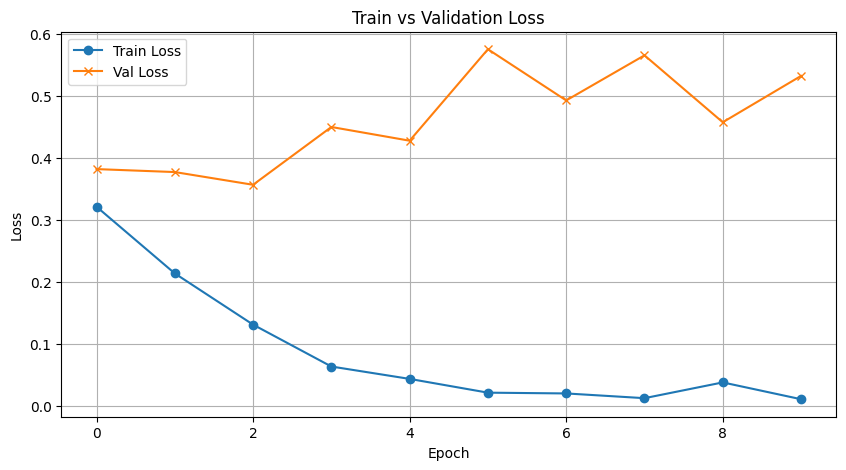

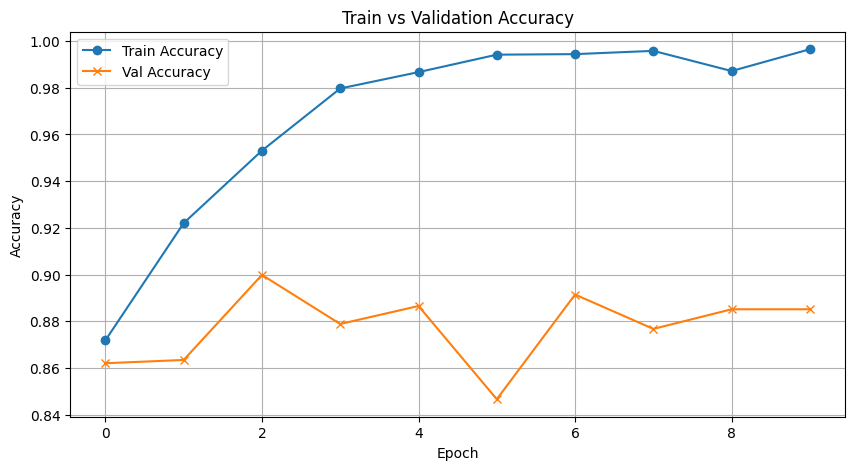


Test Evaluation
Accuracy: 0.8993135011441648
F1 Score: 0.8917909116691001
ROC AUC: 0.9748001047375047
              precision    recall  f1-score   support

      glioma       0.82      0.89      0.85       300
  meningioma       0.85      0.74      0.79       306
     notumor       0.96      0.98      0.97       405
   pituitary       0.94      0.97      0.96       300

    accuracy                           0.90      1311
   macro avg       0.89      0.89      0.89      1311
weighted avg       0.90      0.90      0.90      1311



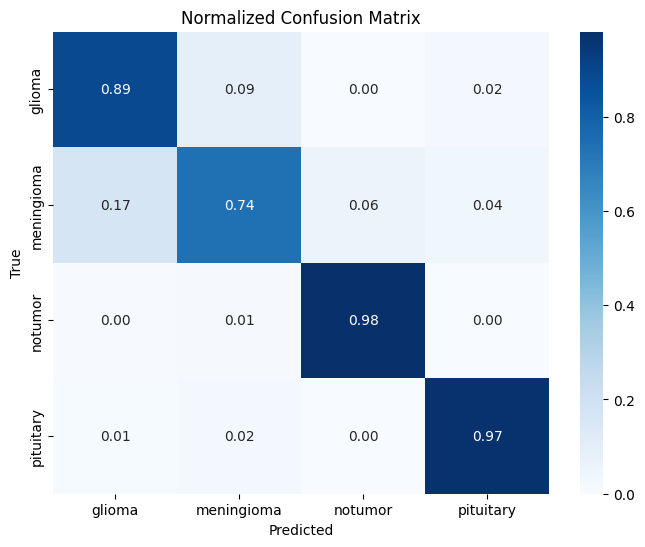

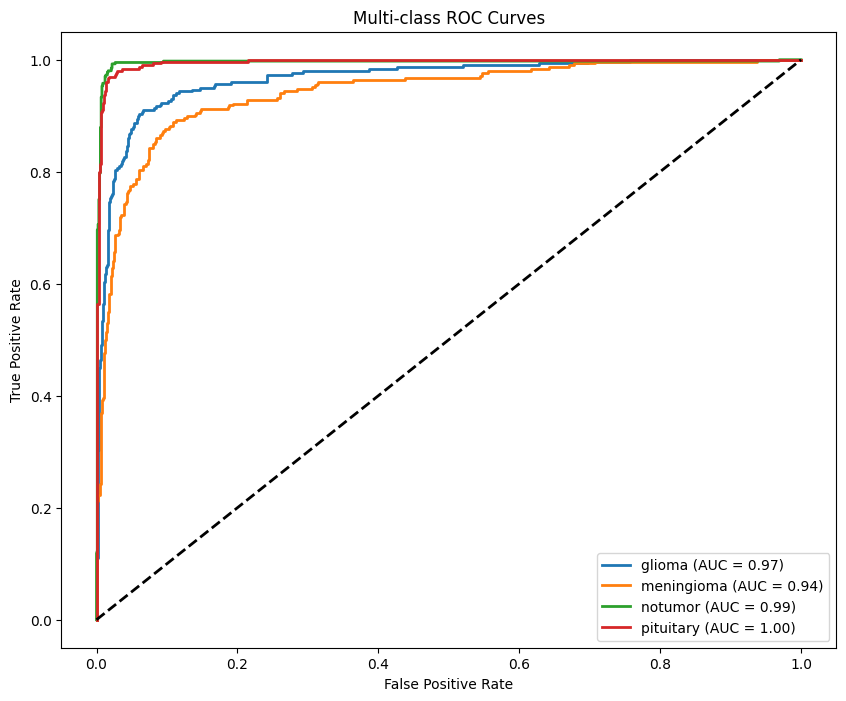

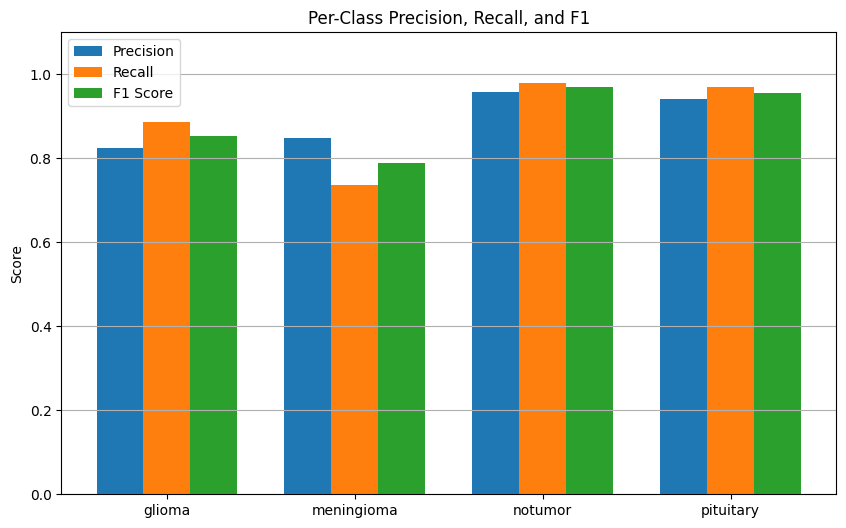

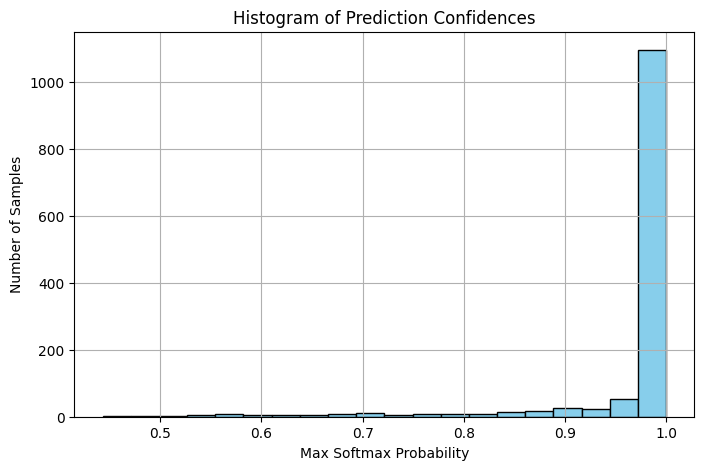

Showing 6 misclassified examples...


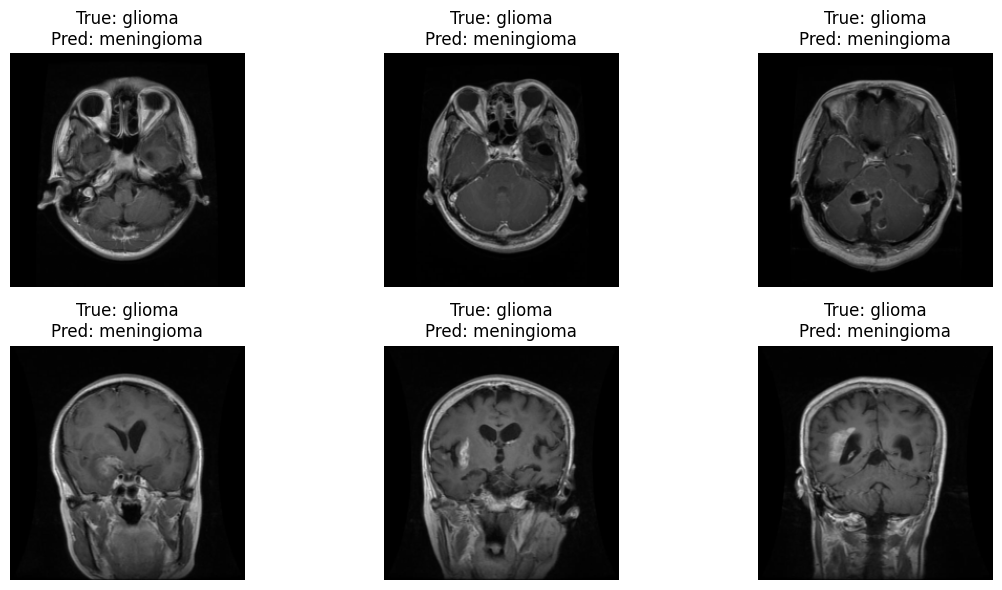

In [ ]:
# ========== TRAINING & VALIDATION ==========
def train(model, loader):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        preds = torch.argmax(outputs, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
    avg_loss = running_loss / len(loader)
    accuracy = correct / total
    return avg_loss, accuracy

def validate(model, loader):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item()
            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    avg_loss = running_loss / len(loader)
    accuracy = correct / total
    return avg_loss, accuracy

def evaluate(model, loader, return_logits=False):
    model.eval()
    all_preds, all_labels, all_logits = [], [], []
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            outputs = model(images)
            preds = torch.argmax(outputs, dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.numpy())
            if return_logits:
                all_logits.extend(outputs.cpu().numpy())
    if return_logits:
        return all_preds, all_labels, np.array(all_logits)
    return all_preds, all_labels

# ========== TRAIN LOOP ==========
train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []
f1s = []

for epoch in range(10):
    train_loss, train_acc = train(model, train_loader)
    val_loss, val_acc = validate(model, val_loader)

    preds, labels = evaluate(model, val_loader)
    f1 = f1_score(labels, preds, average='macro')

    print(f"Epoch {epoch+1}:")
    print(f"  Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}")
    print(f"  Val   Loss: {val_loss:.4f}, Val   Acc: {val_acc:.4f}")
    print(f"  F1 Score (val): {f1:.4f}\n")

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)
    f1s.append(f1)

# ========== METRIC PLOTS ==========
# Loss
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss', marker='o')
plt.plot(val_losses, label='Val Loss', marker='x')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Train vs Validation Loss")
plt.grid(True)
plt.legend()
plt.show()

# Accuracy
plt.figure(figsize=(10, 5))
plt.plot(train_accuracies, label='Train Accuracy', marker='o')
plt.plot(val_accuracies, label='Val Accuracy', marker='x')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Train vs Validation Accuracy")
plt.grid(True)
plt.legend()
plt.show()

# ========== TEST EVALUATION ==========
preds, labels, logits = evaluate(model, test_loader, return_logits=True)
logits_proba = softmax(logits, axis=1)

print("\nTest Evaluation")
print("Accuracy:", accuracy_score(labels, preds))
print("F1 Score:", f1_score(labels, preds, average='macro'))
print("ROC AUC:", roc_auc_score(labels, logits_proba, multi_class='ovr'))
print(classification_report(labels, preds, target_names=class_names))

# Confusion matrix
cm = confusion_matrix(labels, preds)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
plt.figure(figsize=(8, 6))
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title("Normalized Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# ROC curves
plt.figure(figsize=(10, 8))
labels_bin = label_binarize(labels, classes=[0, 1, 2, 3])
for i in range(len(class_names)):
    fpr, tpr, _ = roc_curve(labels_bin[:, i], logits_proba[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'{class_names[i]} (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multi-class ROC Curves")
plt.legend(loc="lower right")
plt.show()

# Per-Class Metrics
precision = precision_score(labels, preds, average=None)
recall = recall_score(labels, preds, average=None)
f1 = f1_score(labels, preds, average=None)

x = np.arange(len(class_names))
width = 0.25
plt.figure(figsize=(10, 6))
plt.bar(x - width, precision, width, label='Precision')
plt.bar(x, recall, width, label='Recall')
plt.bar(x + width, f1, width, label='F1 Score')
plt.xticks(x, class_names)
plt.ylabel("Score")
plt.title("Per-Class Precision, Recall, and F1")
plt.ylim(0, 1.1)
plt.grid(True, axis='y')
plt.legend()
plt.show()

# Confidence histogram
max_probs = np.max(logits_proba, axis=1)
plt.figure(figsize=(8, 5))
plt.hist(max_probs, bins=20, color='skyblue', edgecolor='black')
plt.title("Histogram of Prediction Confidences")
plt.xlabel("Max Softmax Probability")
plt.ylabel("Number of Samples")
plt.grid(True)
plt.show()

# Misclassified samples
misclassified_indices = [i for i, (p, l) in enumerate(zip(preds, labels)) if p != l]
if misclassified_indices:
    print(f"Showing {min(6, len(misclassified_indices))} misclassified examples...")
    misclassified_subset = torch.utils.data.Subset(test_ds, misclassified_indices[:6])
    mis_loader = DataLoader(misclassified_subset, batch_size=6, shuffle=False)

    images, labels = next(iter(mis_loader))
    images = images.to(device)
    outputs = model(images)
    preds = torch.argmax(outputs, dim=1)

    plt.figure(figsize=(12, 6))
    for i in range(len(images)):
        plt.subplot(2, 3, i+1)
        img = images[i].cpu().permute(1, 2, 0).numpy()
        img = (img * 0.5) + 0.5  # denormalize
        plt.imshow(img)
        plt.title(f"True: {class_names[labels[i]]}\nPred: {class_names[preds[i]]}")
        plt.axis("off")
    plt.tight_layout()
    plt.show()